# EfficientRainbow ± FHR on Krull — Atari-100k results (corrected protocol)

**Branch `atari/atari-100k-bbf` · 2026-08-22 · single GB10 GPU · seeds 0 and 1**

Companion to `exp_bbf_fhr_krull_results.ipynb`: the same ± FHR comparison, on the
repo's **EfficientRainbow** recipe — DrQ's "Efficient DQN" (Kostrikov et al. 2021,
Table 4) with the IQN-8 dueling head: NatureCNN encoder (3 conv layers), double DQN,
**fixed** n-step 10 and γ = 0.99 (no annealing), hard target copy every env step,
exponential ε → 0.01 over ~5k steps, replay ratio 2, DrQ shift+intensity augmentation,
Adam (lr 1e-4, eps 1.5e-4, no weight decay). Unlike BBF there are **no
shrink-and-perturb resets and no schedule annealing** — so those sections of the BBF
notebook have no counterpart here.

All arms are trained under the **corrected protocol** (episodic-life training: a life
loss ends the agent's episode while the game continues; full-game final evaluation).
The pre-2026-08-21 EfficientRainbow runs trained under a game-restarting protocol and
live in the archived manifest family `effrainbow100k_runs.v0-gamerestart` — they are
never pooled with these. The FHR arms are **whatever
`experiment.fhr_experiments` in `config_effrainbow_100k.yaml` currently defines** —
one `exp<N>` wing per entry, each adding λ · Huber(order-r recurrence residual) to
the TD loss after a 10k-gradient-step warm-up; every legend states each arm's λ / r.
A config entry matching the BBF comparison's arm makes the FHR effect directly
comparable across recipes.

## 0 · Launch — train whatever the config defines

The cell below drives training straight from **`config_effrainbow_100k.yaml`**: one
subprocess per (arm, seed) — the shared baseline plus one `exp<N>` arm per
`experiment.fhr_experiments` entry, over `experiment.seeds`. Runs already recorded in
`cached/effrainbow100k_runs_manifest.json` are **skipped**, so re-running this notebook
is safe.

* `LAUNCH = False` → analysis-only (default).
* `LAUNCH = True, FORCE_EXP = False` → trains anything **missing** (e.g. a new
  `fhr_experiments` entry you added to the config).
* `LAUNCH = True, FORCE_EXP = True` → **retrains the exp arms with the current config**
  (recorded baselines are never retrained) — use this to rerun the FHR wing with new
  λ / r / agent-block settings against the kept baselines. The old runs stay on disk
  but the manifest re-points `exp<N>` at the new ones.

Training blocks the kernel (~25–45 min per run at batch 32); live logs land in
`cached/logs/effrainbow100k_*.log` and the rank viewer (http://localhost:8501) shows
curves as they train.

In [1]:
import pathlib, sys
EXPS = pathlib.Path.cwd().parents[1] / "src"          # experiments/src
if str(EXPS) not in sys.path:
    sys.path.insert(0, str(EXPS))
import run_fhrdqn_atari100k as launcher
launcher.CONFIG = "config_effrainbow_100k.yaml"       # this notebook's recipe

LAUNCH = True       # flip to True to train from the config
FORCE_EXP = False    # True: retrain exp arms with the current config (never baselines)

if LAUNCH:
    manifests = launcher.launch_all(games=["krull"], experiments=None,
                                    max_workers=1, force=FORCE_EXP)
    print({g: sorted(m["runs"]) for g, m in manifests.items()})
else:
    print("LAUNCH = False — analysing existing runs only")

skipping 4 already-completed run(s)
{'krull': ['baseline', 'exp1', 'exp2', 'exp3', 'exp4']}


In [2]:
import csv, glob, json, pathlib, sys
import numpy as np
import matplotlib.pyplot as plt
import yaml

HERE = pathlib.Path.cwd()
SRC = HERE.parents[2] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from analysis.atari100k import REFERENCE, hns

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})

# The arms under comparison come from the CONFIG, not from hardcoded names:
# baseline + one exp<N> per experiment.fhr_experiments entry, over
# experiment.seeds. The manifest may hold more arms (older sweeps) — ignored.
CFG = yaml.safe_load(open(HERE / "config_effrainbow_100k.yaml"))
FHR_EXPS = {str(k): v for k, v in
            (CFG["experiment"].get("fhr_experiments") or {}).items()}
SEEDS = [str(s) for s in
         (CFG["experiment"].get("seeds") or [CFG["experiment"]["seed"]])]
ARMS = ["baseline"] + [f"exp{k}" for k in sorted(FHR_EXPS, key=int)]

MAN = json.load(open(HERE / "cached" / "effrainbow100k_runs_manifest.json"))

def _overrides(arm):
    return MAN.get("overrides", {}).get(arm) or FHR_EXPS.get(arm[3:], {})

def _arm_label(arm):
    if arm == "baseline":
        return "EfficientRainbow (TD only)"
    ov = _overrides(arm)
    lab = f"λ={ov.get('fhr_weight', '?')}, r={ov.get('fhr_order', '?')}"
    if ov.get("reward_lags"):
        lab += ", +rlags"
    return f"EfficientRainbow + FHR {arm} ({lab})"

# Recorded runs must match what the config now asks for (FORCE_EXP retrains):
def _norm(d):
    return {k: (float(v) if isinstance(v, (int, float))
                and not isinstance(v, bool) else v) for k, v in d.items()}
for k, want in FHR_EXPS.items():
    got = MAN.get("overrides", {}).get(f"exp{k}")
    if got is not None and _norm(got) != _norm(want):
        print(f"WARNING: recorded exp{k} was trained with {got} but the config "
              f"now says {want} — rerun the launch cell with FORCE_EXP = True")

EXP_COLOURS = ["tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
ARM_META = {"baseline": (_arm_label("baseline"), "tab:blue")}
for i, k in enumerate(sorted(FHR_EXPS, key=int)):
    ARM_META[f"exp{k}"] = (_arm_label(f"exp{k}"),
                           EXP_COLOURS[i % len(EXP_COLOURS)])
SEED_LS = dict(zip(SEEDS, ["-", "--", "-.", ":"]))

def load_rewards(run):
    a = np.genfromtxt(HERE / run / "rewards.csv", delimiter=",", names=True)
    return a["reward"], a["steps"].astype(int)

DATA = {}
for arm, (label, colour) in ARM_META.items():
    recorded = MAN["runs"].get(arm, {})
    for seed in SEEDS:
        if seed not in recorded:
            print(f"{label:44s} seed {seed}: no recorded run yet — "
                  f"launch cell trains it")
            continue
        rel = recorded[seed]
        d = {"rew": load_rewards(rel),
             "diag": np.genfromtxt(HERE / rel / "train_diagnostics.csv",
                                   delimiter=",", names=True),
             "eval": (np.genfromtxt(HERE / rel / "eval_scores.csv", delimiter=",",
                                    skip_header=1)[:, 1],
                      json.load(open(HERE / rel / "eval_summary.json"))),
             "dir": rel, "label": label, "colour": colour, "ls": SEED_LS[seed]}
        DATA[(arm, seed)] = d
        print(f"{label:44s} seed {seed}: eval mean {d['eval'][1]['mean']:7.1f}  "
              f"median {d['eval'][1]['median']:7.1f}  HNS {d['eval'][1]['hns_mean']:.3f}")

def smooth(x, k):
    return x if len(x) < k else np.convolve(x, np.ones(k) / k, mode="valid")

EfficientRainbow (TD only)                   seed 0: eval mean  4766.6  median  4815.0  HNS 2.968


EfficientRainbow (TD only)                   seed 1: eval mean  3657.8  median  3860.0  HNS 1.930
EfficientRainbow + FHR exp3 (λ=2, r=8)       seed 0: eval mean  4990.0  median  4370.0  HNS 3.178
EfficientRainbow + FHR exp3 (λ=2, r=8)       seed 1: eval mean  5081.2  median  4910.0  HNS 3.263


## 1 · Training learning curves — reward the agent saw (per life segment)

One point per **agent episode = life segment** (episodic-life protocol), raw game score
(the agent optimises the sign-clipped version; the logger records raw so curves are
comparable). Solid lines: seed 0 · dashed: seed 1 · rolling-25 smoothing.

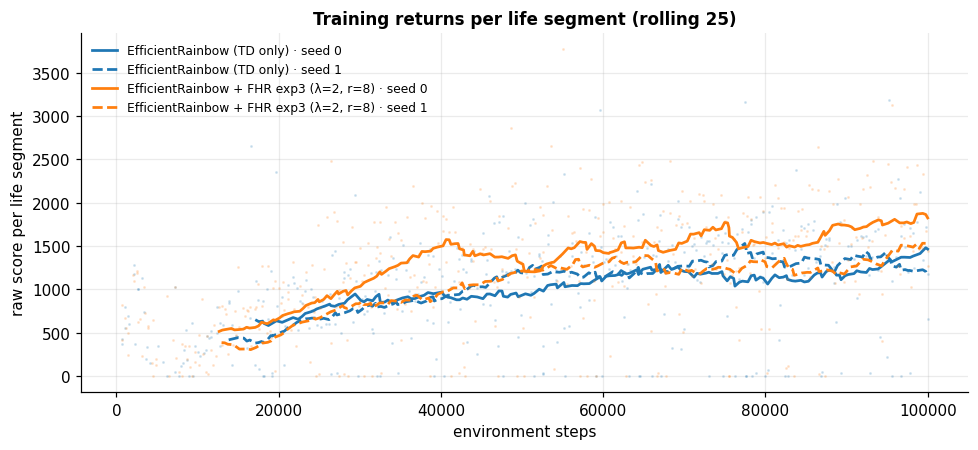

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.2))
K = 25
for (arm, seed), d in DATA.items():
    rew, steps = d["rew"]
    x = np.cumsum(steps)
    ax.plot(x, rew, ".", ms=2, alpha=0.15, color=d["colour"])
    ax.plot(x[K - 1:], smooth(rew, K), d["ls"], lw=1.8, color=d["colour"],
            label=f"{d['label']} · seed {seed}")
ax.set(xlabel="environment steps", ylabel="raw score per life segment",
       title="Training returns per life segment (rolling 25)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()

## 2 · Reconstructed *true* (full-game) reward over training

Krull starts every game with 3 lives, so consecutive life segments are summed in threes
to approximate full-game scores. These are **sums of real logged scores** — only the
game *grouping* is assumed (the 100k cap truncates the last game and the two analysis
ticks can shift one boundary). Behaviour-policy scores; the rigorous full-game
measurement is §3.

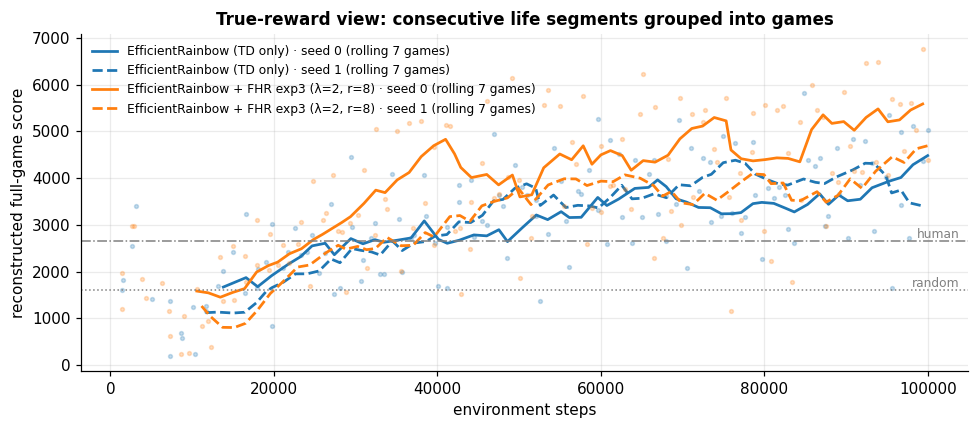

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for (arm, seed), d in DATA.items():
    rew, steps = d["rew"]
    n = len(rew) // 3
    games = rew[:n * 3].reshape(n, 3).sum(axis=1)
    gx = np.cumsum(steps)[:n * 3].reshape(n, 3)[:, -1]
    ax.plot(gx, games, "o", ms=2.5, alpha=0.25, color=d["colour"])
    if n >= 7:
        ax.plot(gx[6:], smooth(games, 7), d["ls"], lw=1.8, color=d["colour"],
                label=f"{d['label']} · seed {seed} (rolling 7 games)")
for m, ls, lab in ((1598.0, ":", "random"), (2665.5, "-.", "human")):
    ax.axhline(m, color="gray", ls=ls, lw=1)
    ax.annotate(lab, (0.99, m), xycoords=("axes fraction", "data"),
                ha="right", va="bottom", fontsize=8, color="gray")
ax.set(xlabel="environment steps", ylabel="reconstructed full-game score",
       title="True-reward view: consecutive life segments grouped into games")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()

## 3 · Final evaluation

Protocol identical to the BBF notebook (`evaluate_policy_atari`): after the 100k-step
budget, **32 complete games** on a fresh env with `terminal_on_life_loss = False` and
`episodic_life = False` (the launcher force-overrides both), ε = 0.001, resets seeded
1000 + episode — so every run scores the *same* 32 start conditions. Raw, unclipped
scores. Left: per-arm means (averaging seed means, whiskers = seed range). Right:
per-seed distributions of the 32 episodes.

EfficientRainbow (TD only)                   seed 0: mean  4766.6  median  4815.0  std  1208.0  min   2660  max   7390


EfficientRainbow (TD only)                   seed 1: mean  3657.8  median  3860.0  std  1174.0  min   2000  max   5540
EfficientRainbow + FHR exp3 (λ=2, r=8)       seed 0: mean  4990.0  median  4370.0  std  1107.7  min   3860  max   6910
EfficientRainbow + FHR exp3 (λ=2, r=8)       seed 1: mean  5081.2  median  4910.0  std   694.1  min   3770  max   7070


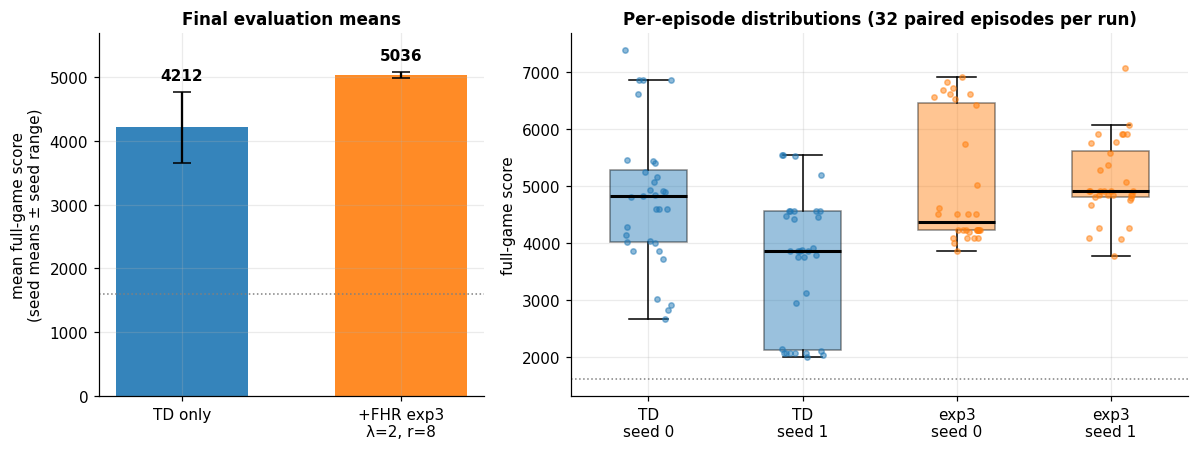

In [5]:
arms = [a for a in ARMS if any((a, s) in DATA for s in SEEDS)]

def _short(arm):
    if arm == "baseline":
        return "TD only"
    ov = _overrides(arm)
    tag = f"+FHR {arm}\nλ={ov.get('fhr_weight', '?')}, r={ov.get('fhr_order', '?')}"
    return tag + ("\n+rlags" if ov.get("reward_lags") else "")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(5.5 + 2.75 * len(arms), 4.2),
                             width_ratios=[1, 1.6])
ymax = 0.0
for i, arm in enumerate(arms):
    seed_means = [DATA[(arm, s)]["eval"][0].mean() for s in SEEDS
                  if (arm, s) in DATA]
    col = ARM_META[arm][1]
    m, top = np.mean(seed_means), max(seed_means)
    a1.bar(i, m, color=col, width=0.6, alpha=0.9,
           yerr=[[m - min(seed_means)], [top - m]], capsize=6)
    a1.annotate(f"{m:.0f}", (i, top), ha="center", va="bottom",
                fontweight="bold", xytext=(0, 6), textcoords="offset points")
    ymax = max(ymax, top)
a1.set_ylim(0, ymax * 1.12)
a1.axhline(1598.0, color="gray", ls=":", lw=1)
a1.set(xticks=range(len(arms)), xticklabels=[_short(a) for a in arms],
       ylabel="mean full-game score\n(seed means ± seed range)",
       title="Final evaluation means")
pos, labels = 0, []
rng = np.random.default_rng(0)
for arm in arms:
    for s in SEEDS:
        if (arm, s) not in DATA:
            continue
        d = DATA[(arm, s)]
        sc = d["eval"][0]
        bp = a2.boxplot([sc], positions=[pos], widths=0.5, patch_artist=True,
                        medianprops=dict(color="black", lw=2), showfliers=False)
        bp["boxes"][0].set(facecolor=d["colour"], alpha=0.45)
        a2.plot(pos + rng.uniform(-0.15, 0.15, len(sc)), sc, "o", ms=3.5,
                alpha=0.5, color=d["colour"])
        labels.append(f"{'TD' if arm == 'baseline' else arm}\nseed {s}")
        pos += 1
a2.axhline(1598.0, color="gray", ls=":", lw=1)
a2.set(xticks=range(pos), xticklabels=labels, ylabel="full-game score",
       title="Per-episode distributions (32 paired episodes per run)")
for (arm, s), d in DATA.items():
    sc = d["eval"][0]
    print(f"{d['label']:44s} seed {s}: mean {sc.mean():7.1f}  "
          f"median {np.median(sc):7.1f}  std {sc.std(ddof=1):7.1f}  "
          f"min {sc.min():6.0f}  max {sc.max():6.0f}")
plt.tight_layout()

## 4 · Against the published methods — and the BBF port

Published values verified against primary sources (EfficientZero Table 1; BBF paper
Table A.1) on 2026-08-22. The BBF-port bars (single seed, RR 2, no SPR/PER) come from
the companion notebook for cross-recipe context. Published numbers average 30–100
seeds; ours are 1–2 seed means.

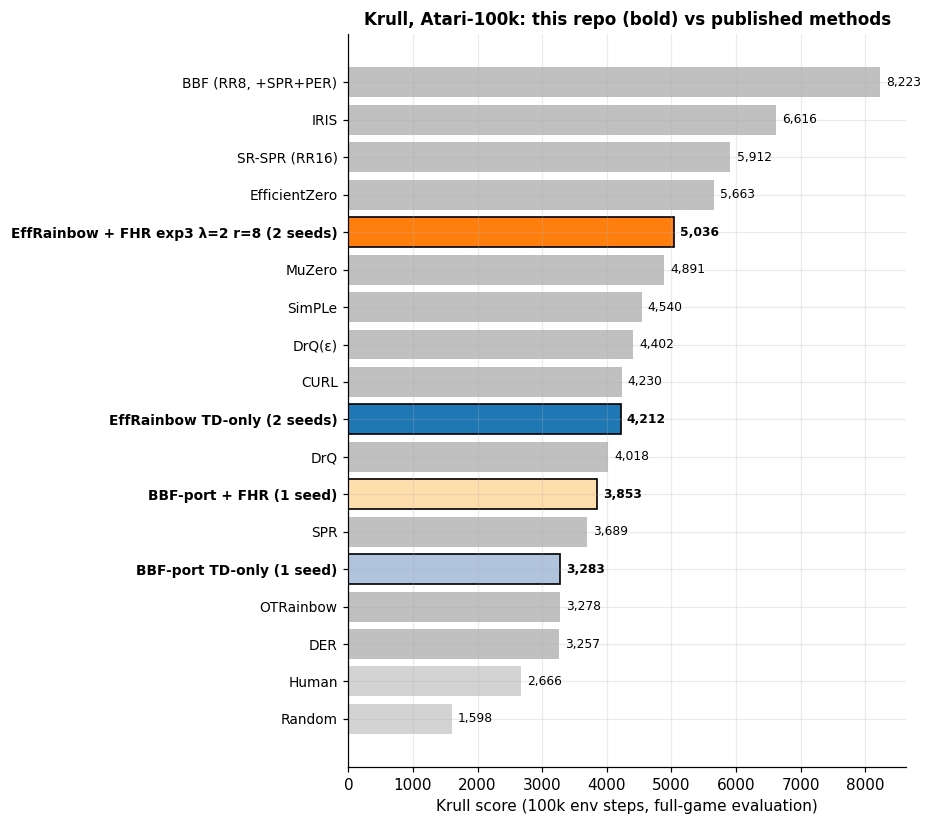

In [6]:
published = [
    ("Random", 1598.0), ("Human", 2665.5), ("DER", 3256.9), ("OTRainbow", 3277.9),
    ("SPR", 3688.9), ("DrQ", 4018.1), ("CURL", 4229.6), ("DrQ(ε)", 4402.1),
    ("SimPLe", 4539.9), ("MuZero", 4890.8), ("EfficientZero", 5663.3),
    ("SR-SPR (RR16)", 5911.8), ("IRIS", 6616.4), ("BBF (RR8, +SPR+PER)", 8223.4),
]
def arm_mean(arm):
    return float(np.mean([DATA[(arm, s)]["eval"][0].mean()
                          for s in SEEDS if (arm, s) in DATA]))
def n_seeds(arm):
    return sum((arm, s) in DATA for s in SEEDS)

ours = []
for arm in ARMS:
    if not n_seeds(arm):
        continue
    if arm == "baseline":
        lab = f"EffRainbow TD-only ({n_seeds(arm)} seeds)"
    else:
        ov = _overrides(arm)
        lab = (f"EffRainbow + FHR {arm} "
               f"λ={ov.get('fhr_weight', '?')} r={ov.get('fhr_order', '?')}"
               f"{' +rlags' if ov.get('reward_lags') else ''} "
               f"({n_seeds(arm)} seeds)")
    ours.append((lab, arm_mean(arm), ARM_META[arm][1]))
ours += [("BBF-port TD-only (1 seed)", 3282.8, "lightsteelblue"),
         ("BBF-port + FHR (1 seed)", 3853.4, "navajowhite")]
rows = sorted([(l, v, "silver", False) for l, v in published]
              + [(l, v, c, True) for l, v, c in ours], key=lambda r: r[1])
fig, ax = plt.subplots(figsize=(8.5, 6.4 + 0.3 * len(ours)))
for y, (label, scr, col, is_ours) in enumerate(rows):
    ax.barh(y, scr, color=col if is_ours else
            ("lightgray" if label in ("Random", "Human") else "silver"),
            edgecolor="black" if is_ours else "none", lw=1.1)
    ax.annotate(f"{scr:,.0f}", (scr, y), va="center", ha="left", xytext=(4, 0),
                textcoords="offset points", fontsize=8,
                fontweight="bold" if is_ours else "normal")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows], fontsize=9)
for tick, (_, _, _, is_ours) in zip(ax.get_yticklabels(), rows):
    if is_ours:
        tick.set_fontweight("bold")
ax.set(xlabel="Krull score (100k env steps, full-game evaluation)",
       title="Krull, Atari-100k: this repo (bold) vs published methods")
plt.tight_layout()

## 5 · The objective — TD loss, regulariser, total

Same construction as the BBF notebook: both arms minimise the IQN quantile-Huber TD
loss; the FHR arm adds λ·Huber(ρ) with learned order-4 coefficients (own optimiser
group, no weight decay). No resets exist in this recipe, so the curves are smooth.
Rolling-500 smoothing; seed 0 solid, seed 1 dashed.

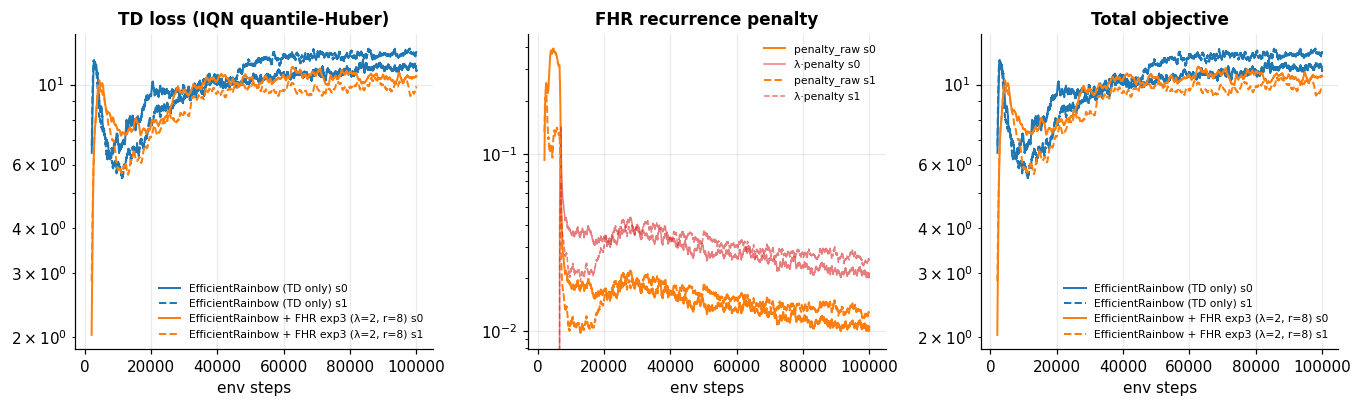

In [7]:
# Diagnostics cadence differs across runs (per-env-step in the early runs,
# per-training-call after train_frequency_steps went 1 -> 32), so the row
# index is NOT a shared axis: map rows onto env steps and smooth over a
# fixed fraction of the run (~0.5%) rather than a fixed row count.
W0, TMAX = CFG["training"]["warmup_steps"], CFG["training"]["max_env_steps"]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
for (arm, seed), d in DATA.items():
    g = d["diag"]
    k = max(5, len(g) // 200)
    x = np.linspace(W0, TMAX, len(g))[k - 1:]
    axes[0].plot(x, smooth(g["td_loss"], k), d["ls"], lw=1.3, color=d["colour"],
                 label=f"{d['label']} s{seed}")
    lam = g["lambda_eff"]
    pen_w = np.where(np.isnan(g["penalty_raw"]), 0.0, g["penalty_raw"]) * lam
    axes[2].plot(x, smooth(g["td_loss"] + pen_w, k), d["ls"], lw=1.3,
                 color=d["colour"], label=f"{d['label']} s{seed}")
    if np.nanmax(lam) > 0:
        axes[1].plot(x, smooth(np.nan_to_num(g["penalty_raw"]), k), d["ls"],
                     lw=1.3, color=d["colour"], label=f"penalty_raw s{seed}")
        axes[1].plot(x, smooth(pen_w, k), d["ls"], lw=1, alpha=0.6,
                     color="tab:red", label=f"λ·penalty s{seed}")
axes[0].set(title="TD loss (IQN quantile-Huber)", xlabel="env steps", yscale="log")
axes[1].set(title="FHR recurrence penalty", xlabel="env steps", yscale="log")
axes[2].set(title="Total objective", xlabel="env steps", yscale="log")
for a in axes:
    a.legend(fontsize=7)
plt.tight_layout()

## 6 · FHR internals — learned recurrence coefficients (one figure per config-defined FHR arm, all seeds)

exp3 seed 0 final c = [1.069, -0.05, 0.016, -0.007, 0.004, 0.017, -0.022, -0.027]  sum = 1.000
exp3 seed 1 final c = [1.109, -0.048, -0.011, -0.028, 0.018, 0.014, -0.025, -0.029]  sum = 1.000


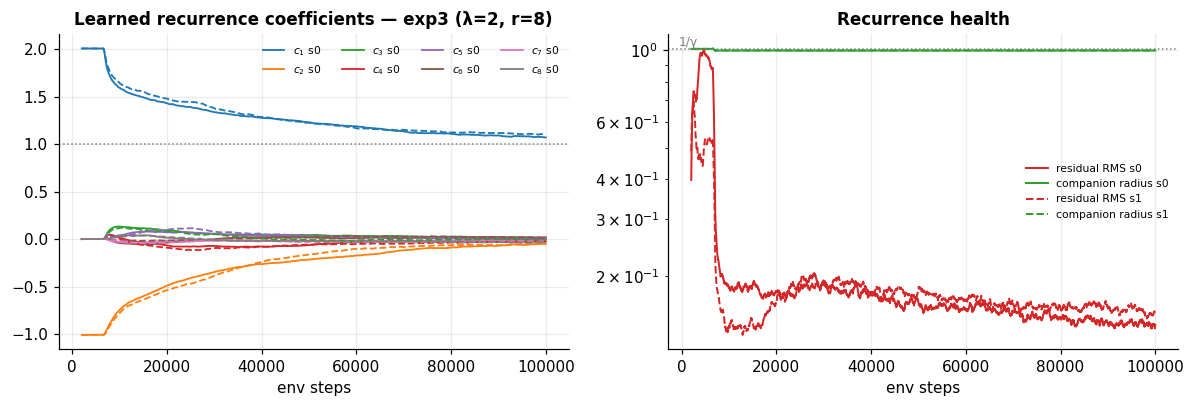

In [8]:
W0, TMAX = CFG["training"]["warmup_steps"], CFG["training"]["max_env_steps"]
for arm in [a for a in ARMS if a != "baseline"
            and any((a, s) in DATA for s in SEEDS)]:
    ov = _overrides(arm)
    order = int(ov.get("fhr_order", CFG["agent"]["fhr_order"]))
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
    for seed in SEEDS:
        if (arm, seed) not in DATA:
            continue
        g = DATA[(arm, seed)]["diag"]
        k = max(5, len(g) // 200)      # cadence-independent smoothing (see §5)
        x = np.linspace(W0, TMAX, len(g))[k - 1:]
        for j in range(1, order + 1):
            a1.plot(x, smooth(g[f"c_{j}"], k), SEED_LS[seed], lw=1.2,
                    color=f"C{(j - 1) % 10}",
                    label=f"$c_{{{j}}}$ s{seed}" if seed == SEEDS[0] else None)
        a2.plot(x, smooth(g["residual_rms"], k), SEED_LS[seed], lw=1.3,
                color="tab:red", label=f"residual RMS s{seed}")
        a2.plot(x, smooth(g["companion_radius"], k), SEED_LS[seed], lw=1.3,
                color="tab:green", label=f"companion radius s{seed}")
    a1.axhline(1.0, color="gray", ls=":", lw=1)
    a1.set(title=(f"Learned recurrence coefficients — {arm} "
                  f"(λ={ov.get('fhr_weight', '?')}, r={ov.get('fhr_order', '?')})"),
           xlabel="env steps")
    a1.legend(ncol=4, fontsize=7)
    a2.axhline(1 / 0.99, color="gray", ls=":", lw=1)
    a2.annotate("1/γ", (0.02, 1 / 0.99), xycoords=("axes fraction", "data"),
                fontsize=8, color="gray", va="bottom")
    a2.set(title="Recurrence health", xlabel="env steps", yscale="log")
    a2.legend(fontsize=7)
    plt.tight_layout()
    for seed in SEEDS:
        if (arm, seed) in DATA:
            g = DATA[(arm, seed)]["diag"]
            print(f"{arm} seed {seed} final c = "
                  f"{[round(float(g[f'c_{i}'][-1]), 3) for i in range(1, order + 1)]}"
                  f"  sum = {float(g['sum_c'][-1]):.3f}")

## 7 · Low-rank structure — Hankel effective rank across training

Same probe as the BBF notebook (`hankel_sweep.csv`: one greedy rollout every ~40
episodes, effective rank of the Hankel matrix of the Q/V sequence).

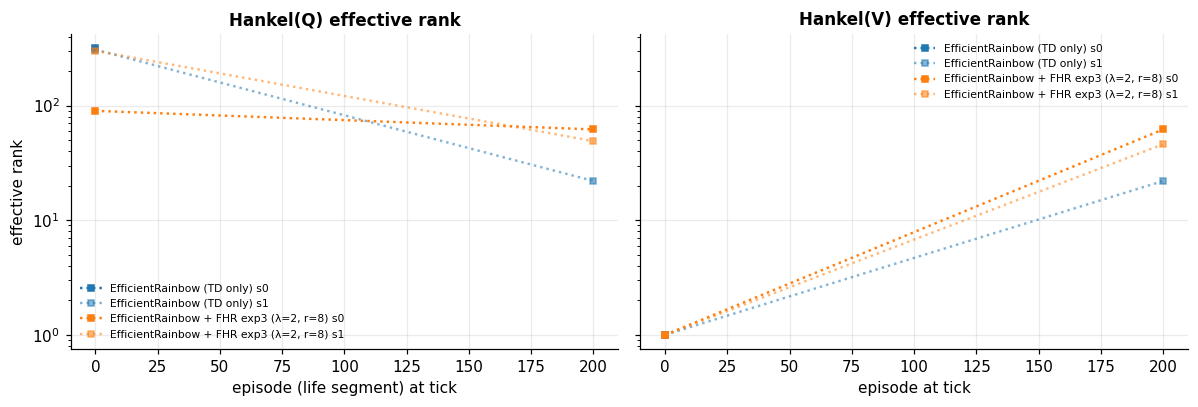

In [9]:
def load_sweep(run):
    rows = list(csv.DictReader(open(HERE / run / "hankel_sweep.csv")))
    out = {}
    for r in rows:
        out.setdefault(r["matrix"], []).append((int(r["episode"]),
                                                float(r["eff_rank"])))
    return out

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for (arm, seed), d in DATA.items():
    sw = load_sweep(d["dir"])
    for mat, ax in (("Hankel Q", a1), ("Hankel V", a2)):
        pts = sorted(sw.get(mat, []))
        ax.plot([p[0] for p in pts], [p[1] for p in pts], "s:", lw=1.6, ms=4,
                color=d["colour"], alpha=1.0 if seed == "0" else 0.55,
                label=f"{d['label']} s{seed}")
a1.set(title="Hankel(Q) effective rank", xlabel="episode (life segment) at tick",
       ylabel="effective rank", yscale="log")
a2.set(title="Hankel(V) effective rank", xlabel="episode at tick", yscale="log")
a1.legend(fontsize=7); a2.legend(fontsize=7)
plt.tight_layout()

## 8 · Gameplay — final policies (evaluation seed 1000, full game, ε = 0.001)

One clip per config-defined arm (seed-0 runs, median-scoring eval episode).
The last two columns are the **published pretrained world-model agents**
(IRIS, DIAMOND — Atari-100k Krull checkpoints) rolled out under the same
seeded protocol, for cross-family comparison; the full analysis lives in
`exp_worldmodel_krull_comparison.ipynb`.

In [10]:
from IPython.display import HTML

cols = [("EfficientRainbow (TD only)", "effrainbow_baseline_seed0_score*")]
cols += [(f"EfficientRainbow + FHR {arm}", f"effrainbow_{arm}_seed0_score*")
         for arm in ARMS if arm != "baseline"]
cols += [("IRIS (pretrained)", "iris_score*"),
         ("DIAMOND (pretrained)", "diamond_score*")]
html = "<table><tr>"
for name, pat in cols:
    hits = sorted(glob.glob(str(HERE / "videos" / (pat + ".mp4"))),
                  key=lambda p: int(p.rsplit("score", 1)[-1][:-4]))
    if not hits:
        html += f"<td><b>{name}</b><br>(video pending)</td>"
        continue
    rel = pathlib.Path(hits[-1]).relative_to(HERE)
    score = pathlib.Path(hits[-1]).stem.split("score")[-1]
    html += (f"<td style='text-align:center;padding:0 10px'><b>{name}</b><br>"
             f"<span style='color:gray'>this game: {score} points</span><br>"
             f"<video src='{rel}' controls width='260'></video></td>")
html += "</tr></table>"
HTML(html)

EfficientRainbow (TD only)this game: 4830 points,EfficientRainbow + FHR exp3this game: 4560 points,IRIS (pretrained)this game: 8390 points,DIAMOND (pretrained)this game: 11480 points


## 9 · Conclusions — and the cross-recipe synthesis

In [ ]:
print("Recipe x arm matrix (Krull, corrected protocol, full-game eval):\n")
rows = []
for arm in ARMS:
    means = [DATA[(arm, s)]["eval"][0].mean() for s in SEEDS
             if (arm, s) in DATA]
    if not means:
        print(f"  ({arm}: no recorded runs yet — skipped)")
        continue
    rows.append(("EffRainbow TD-only" if arm == "baseline"
                 else f"EffRainbow + FHR {arm}", means))
rows += [("BBF-port TD-only", [3282.8]),
         ("BBF-port + FHR",   [3853.4])]
for name, means in rows:
    seeds = " / ".join(f"{m:.0f}" for m in means)
    print(f"  {name:22s} seed means: {seeds:>13s}   arm mean: {np.mean(means):7.1f}"
          f"   HNS {hns(float(np.mean(means)), 'Krull'):.3f}")

Recipe × arm matrix (Krull, corrected protocol, full-game eval):

  EffRainbow TD-only     seed means:   4767 / 3658   arm mean:  4212.2   HNS 2.449
  EffRainbow + FHR exp3  seed means:   4990 / 5081   arm mean:  5035.6   HNS 3.220
  BBF-port TD-only       seed means:          3283   arm mean:  3282.8   HNS 1.578
  BBF-port + FHR         seed means:          3853   arm mean:  3853.4   HNS 2.113
